In [2]:
import sys
from pathlib import Path
PROJECT_ROOT = Path(sys.prefix).parent
%cd {PROJECT_ROOT}

/home/younes/younes/Projects/Python/barid_internship


In [3]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [192]:
import polars as pl
import altair as alt

# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS
from coreforecast.scalers import boxcox, inv_boxcox, boxcox_lambda

# import calendar
from utilsforecast.plotting import plot_series as plot_series_utils
from fpppy.utils import plot_series, plot_series_stacked, plot_diagnostics

# from scipy.stats import pearsonr
# from plotly import express as px
# from pathlib import Path
# from itertools import chain
from typing import Optional

import importlib
import lib
import read_data

importlib.reload(lib)

cfg = pl.Config()
cfg.set_tbl_width_chars(10000)
cfg.set_fmt_str_lengths(100)
cfg.set_tbl_cols(-1)
cfg.set_tbl_rows(10)

polars.config.Config

In [ ]:
def make_timeseries(
    df: pl.DataFrame,
    y: str,
    ds: str = "Date_depot",
    blambda: float = 1,
) -> pl.DataFrame:
    return df.select(
        ds=ds,
        y=pl.col(y).map_batches(lambda s: boxcox(s.to_numpy(), blambda)),
        unique_id=pl.lit("all"),
    )

In [5]:
def complete_operations(
    df: pl.DataFrame,
    starting_states: list = ["depot"],
    end_states: list = ["liv"],
) -> pl.DataFrame:
    return (
        df
        .filter(
            pl.col("status_code").first().over("id").is_in(starting_states),
            pl.col("status_code").last().over("id").is_in(end_states),
        )
    )

In [50]:
hijri_year_weeks = int(354.37 / 7)

In [6]:
cabs_inter = set(read_data.read_smi_envoisbyproduitintern_many()["codeenvoi_"])

In [ ]:
fields = (
    pl.read_parquet("data/cab_dfs/fields.parquet")
    .filter(Etat="V")
    .filter(pl.col("Cab").is_in(cabs_inter))
    .filter(pl.col("Date_depot").ge(pl.date(2023, 1, 1)))
    .cast({"Id": pl.String})
    .sort("Date_depot")
    .rename({"Poids_global_en_KG": "weight_kg"})
    .drop_nulls("weight_kg")
)

# operations = (
#     pl.read_parquet("data/cab_dfs/operations.parquet")
#     .filter(pl.col("cab").is_in(cabs_inter))
#     .filter(is_valid="V")
# )

In [171]:
base_df = fields.pipe(
    lib.aggregate_by_date,
    freq="7d",
    value_col="weight_kg",
    date_col="Date_depot",
    total_col="total_weight",
    mean_col="mean_weight",
    std_col="std_weight",
)


# print(df)
chart = (
    alt.Chart(base_df)
    .mark_line(point=True)
    .encode(
        x="Date_depot:T",
        y=alt.Y("total_weight:Q"),
    )
    .properties(width=1100)
)
chart

alt.Chart(...)

In [ ]:
# blambda = boxcox_lambda(base_df["total_weight"], "guerrero", hijri_year_weeks)
# base_df["adjusted_total_weight"] = lib.auto_boxcox(base_df["total_weight"])
# lib.auto_boxcox(base_df["total_weight"], "guerrero", hijri_year_weeks)
# blambda

# boxcox_lambda(base_df["total_weight"], "guerrero", hijri_year_weeks), boxcox_lambda(
#     base_df["total_weight"], "loglik", hijri_year_weeks
# )
# plt.plot(lib.auto_boxcox(base_df["total_weight"], "guerrero", hijri_year_weeks))
df = base_df.with_columns(
    adjusted_total_weight=lib.auto_boxcox(
        base_df["total_weight"], "guerrero", hijri_year_weeks
    )
)
base_chart = alt.Chart(df).mark_line().encode(x="Date_depot").properties(width=1000)
chart = alt.layer(
    base_chart.encode(
        y=alt.Y(
            "adjusted_total_weight:Q",
            axis=alt.Axis(title="Adjusted Weight", orient="left"),
        )
    ),
    base_chart.encode(
        y=alt.Y(
            "total_weight:Q",
            axis=alt.Axis(title="Total Weight", orient="right"),
        ),
        color=alt.value("red"),
    ),
).resolve_scale(y="independent")
chart

alt.LayerChart(...)

In [126]:
chart = (
    alt.Chart(
        fields.pipe(
            lib.aggregate_by_date,
            freq="7d",
            value_col="weight_kg",
            date_col="Date_depot",
            total_col="total_weight",
            mean_col="mean_weight",
        )
    )
    .mark_point()
    .encode(
        x="total_weight:Q",
        y="count:Q",
        tooltip=[
            "Date_depot",
            # "total_weight:Q",
            # "count:Q",
        ],
        color=alt.Color(
            "Date_depot",
            scale=alt.Scale(scheme="rainbow"),
        ),
    )
    # .properties(width=1100)
)
chart

alt.Chart(...)

In [ ]:
levels: list[int | float] = [80, 95]

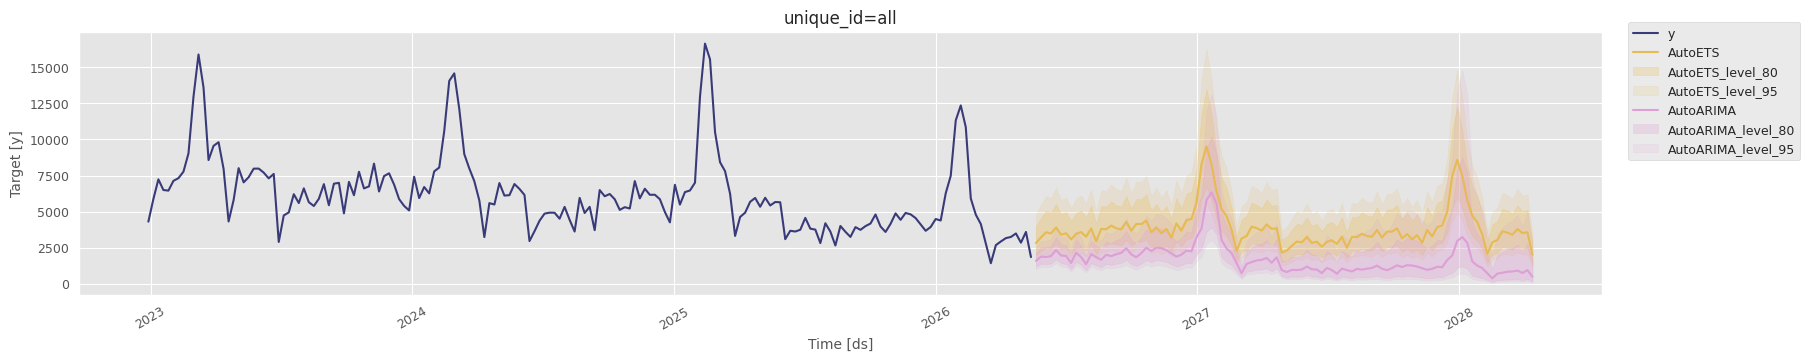

In [ ]:
# blambda = boxcox_lambda(base_df["total_weight"], "loglik", hijri_year_weeks)
blambda = 0

df = base_df.select(
    ds=pl.col("Date_depot"),
    y=pl.col("total_weight").map_batches(lambda s: boxcox(s, blambda)),
    unique_id=pl.lit("all"),
)


sf = StatsForecast(
    models=[
        AutoETS(
            season_length=hijri_year_weeks,
            model="AAA",
            damped=True,
        ),
        AutoARIMA(
            season_length=hijri_year_weeks,
        ),
    ],
    freq="1w",
)

fc = sf.forecast(df=df, h=100, level=levels)

sf.plot(
    df.with_columns(
        pl.exclude("unique_id", "ds").map_batches(
            lambda s: inv_boxcox(s.to_numpy(), blambda)
        )
    ).to_pandas(),
    fc.with_columns(
        pl.exclude("unique_id", "ds").map_batches(
            lambda s: inv_boxcox(s.to_numpy(), blambda)
        )
    ).to_pandas(),
    level=levels,
)

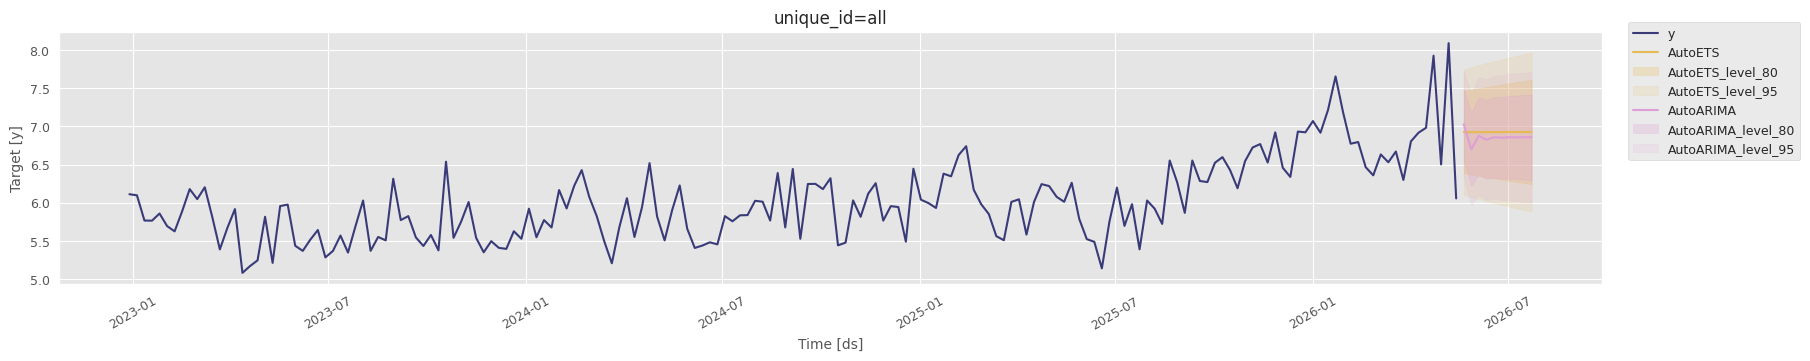

In [162]:
df = base_df.select(
    ds=pl.col("Date_depot"),
    y="std_weight",
    unique_id=pl.lit("all"),
)

sf = StatsForecast(
    models=[
        AutoETS(
            # season_length=hijri_year_weeks,
            model="MAN",
            damped=True,
        ),
        AutoARIMA(
            # season_length=hijri_year_weeks,
            seasonal=False,
        ),
    ],
    freq="1w",
)
fc = sf.forecast(df=df, h=10, level=levels)
sf.plot(df, fc, level=levels)

In [72]:
print(df.to_pandas().head())
print(df.to_pandas().columns)
print(df.to_pandas()["unique_id"].nunique())

      ds     y unique_id
0  19355   799       all
1  19362  1097       all
2  19369  1447       all
3  19376  1215       all
4  19383  1243       all
Index(['ds', 'y', 'unique_id'], dtype='object')
1
